In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [6]:
print(mnist.DESCR)


**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [7]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [8]:
mnist.data.shape

(70000, 784)

In this activity, you will use the MNIST handwritten digit dataset to explore and compare different ensemble learning algorithms.

In [9]:
# You will work with the MNIST dataset containing handwritten digits labeled 0–9.
# Use 30,000 instances for training
# using 5,000 instances for testing

X_train, y_train = mnist.data[:30000], mnist.target[:30000]
X_test, y_test = mnist.data[30000:35000], mnist.target[30000:35000]


In [10]:
X_train.shape, y_train.shape

((30000, 784), (30000,))

In [11]:
X_test.shape, y_test.shape

((5000, 784), (5000,))

Part 1 — Implementation

In [12]:
# 1. Train several classifiers individually, such as:
# Random Forest
import numpy as np
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

In [13]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)

In [14]:
# SGD Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(loss="log_loss", random_state=42, n_jobs=-1)
sgd_clf.fit(X_train, y_train)
y_pred_sgd = sgd_clf.predict(X_test)

In [15]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB
nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)

In [16]:
# 2. Combine these models into an ensemble classifier using:
# Hard voting
from sklearn.ensemble import VotingClassifier
voting_clf_hard = VotingClassifier(
    estimators=[('rf', rnd_clf), ('knn', knn_clf), ('sgd', sgd_clf), ('nb', nb_clf)],
    voting='hard'
)
voting_clf_hard.fit(X_train, y_train)
y_pred_voting_hard = voting_clf_hard.predict(X_test)

In [17]:
# Soft voting.
voting_clf_soft = VotingClassifier(
    estimators=[('rf', rnd_clf), ('knn', knn_clf), ('sgd', sgd_clf), ('nb', nb_clf)],
    voting='soft'
)
voting_clf_soft.fit(X_train, y_train)
y_pred_voting_soft = voting_clf_soft.predict(X_test)


c:\Users\longt\anaconda3\Lib\site-packages\sklearn\linear_model\_base.py:372: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))


In [18]:
# 3. Compare performance:
# How does the ensemble perform compared to each individual classifier?
from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("SGD Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Voting Classifier (Hard) Accuracy:", accuracy_score(y_test, y_pred_voting_hard))
print("Voting Classifier (Soft) Accuracy:", accuracy_score(y_test, y_pred_voting_soft))

Random Forest Accuracy: 0.9622
KNN Accuracy: 0.9644
SGD Accuracy: 0.8594
Naive Bayes Accuracy: 0.8086
Voting Classifier (Hard) Accuracy: 0.9456
Voting Classifier (Soft) Accuracy: 0.8582


after training the data and model with different classiferrs and using hard and soft ensemles, i can say that the ensemble methods perform worse than just using a one of the other models alone. Random forest and KNN performed very well alone while SDG and naive bayes seems have lower accuracy. this seems to have influence the accuracy for the hard votting classifer slightly since it works by getting the average highest-class count, while soft votting seems to be influenced more by naive bayes b/c its the lowest accuracy score compared to the other models. from what i can tell, you would want to use ensemble methods if you want to find the average performance between models, but its really used for cases when the model looks at specifci part of the data. baically, you want to use soft when you have alot of low performing models.

In [19]:
from sklearn.metrics import confusion_matrix
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("SGD Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sgd))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Voting Classifier (Hard) Confusion Matrix:\n", confusion_matrix(y_test, y_pred_voting_hard))
print("Voting Classifier (Soft) Confusion Matrix:\n", confusion_matrix(y_test, y_pred_voting_soft))

Random Forest Confusion Matrix:
 [[467   0   1   0   1   0   0   0   4   0]
 [  0 568   4   4   0   0   1   1   0   1]
 [  2   1 468   2   2   0   2   4   5   0]
 [  0   0   6 479   0   5   0   3   5   5]
 [  2   1   0   0 464   0   5   2   2   8]
 [  1   4   1   9   0 421   3   0   2   0]
 [  3   1   0   0   0   5 481   0   0   0]
 [  1   3   5   2   2   0   0 503   1   8]
 [  0   1   6   5   2   5   3   0 467   9]
 [  2   0   0   7   6   3   0   4   6 493]]
KNN Confusion Matrix:
 [[468   1   2   0   0   0   1   1   0   0]
 [  0 575   1   1   0   0   0   2   0   0]
 [  8   2 466   0   2   1   2   5   0   0]
 [  1   1   3 479   0   7   0   4   5   3]
 [  2   4   0   1 465   0   2   1   1   8]
 [  1   4   1   9   0 419   6   0   1   0]
 [  1   2   0   0   0   1 486   0   0   0]
 [  0   7   1   1   2   0   0 508   0   6]
 [  1  11   6  10   3  11   1   2 449   4]
 [  2   0   0   3   3   2   0   3   1 507]]
SGD Confusion Matrix:
 [[440   0   6   5   3  12   3   1   3   0]
 [  0 532   4  1

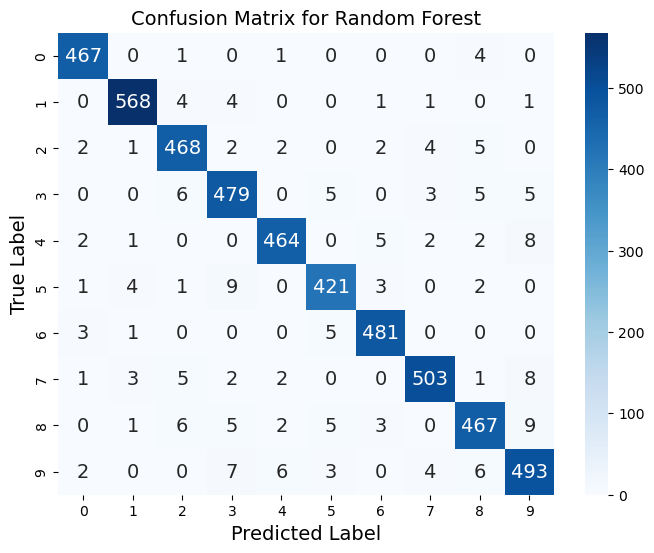

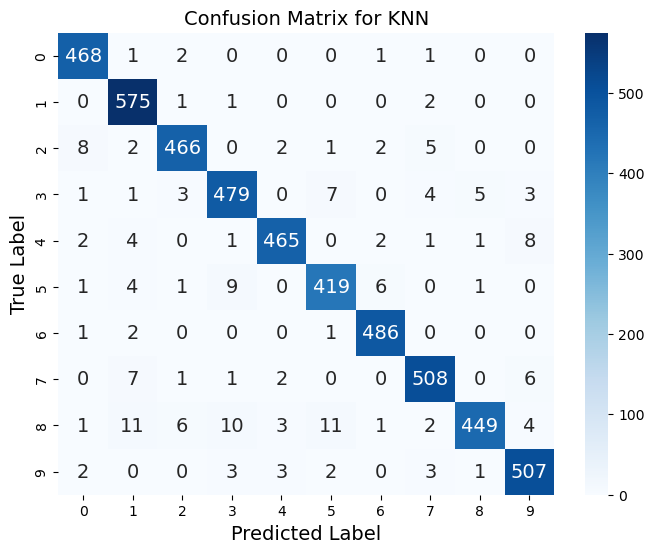

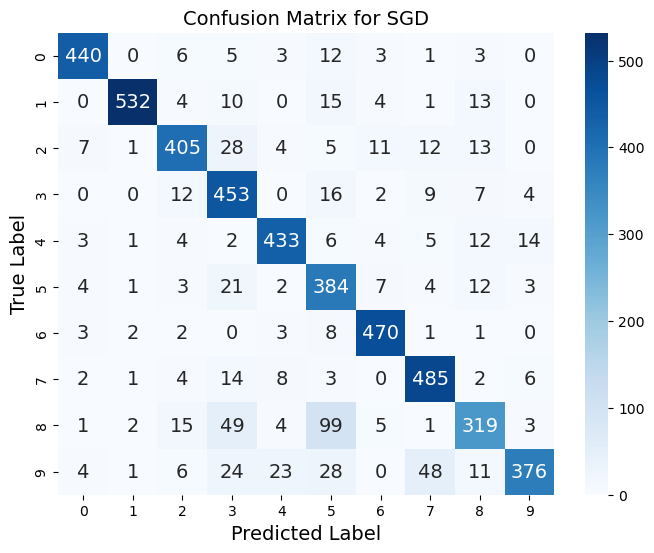

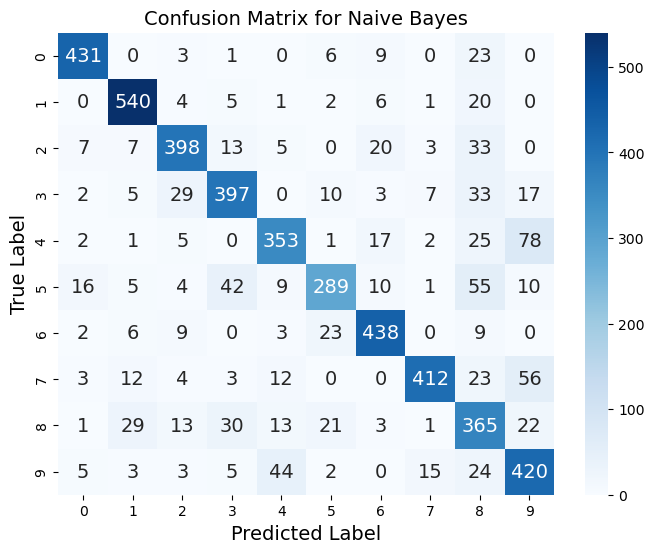

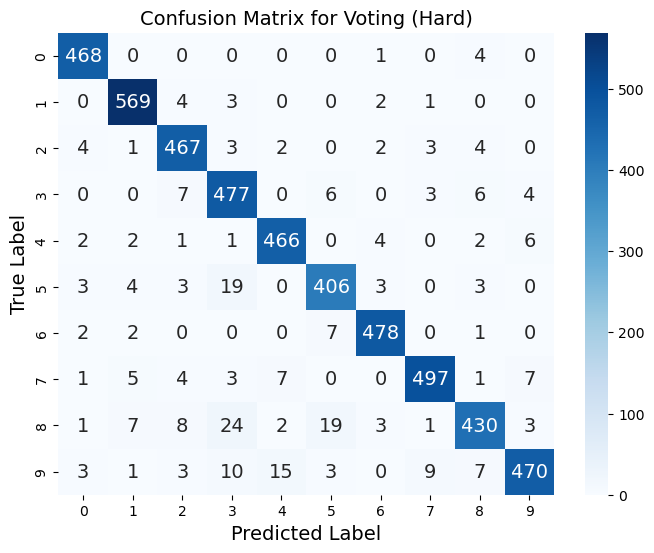

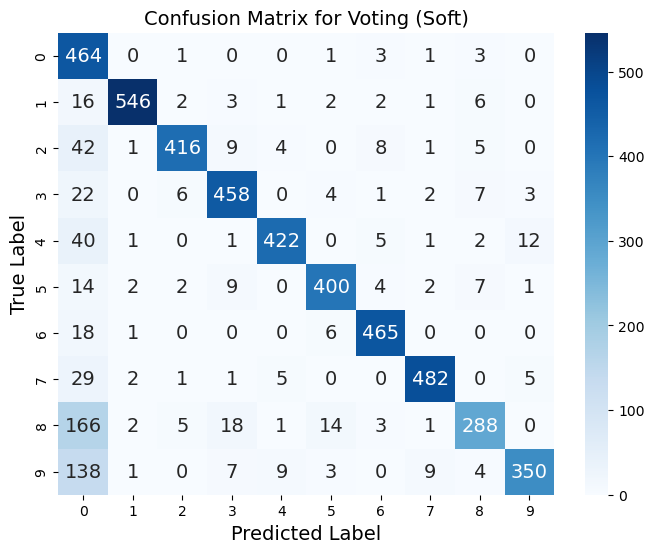

In [20]:
# matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
models = {
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "SGD": y_pred_sgd,
    "Naive Bayes": y_pred_nb,
    "Voting (Hard)": y_pred_voting_hard,
    "Voting (Soft)": y_pred_voting_soft
}
for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()